# <span style = "color : green"> Housing Price Prediction </span>

***

Your neighbor is a real estate agent and wants some help predicting housing prices for regions in the USA. It would be great if you could somehow create a model for her that allows her to put in a few features of a house and returns back an estimate of what the house would sell for.

She has asked you if you could help her out with your new data science skills. You say yes, and decide that Linear Regression might be a good path to solve this problem!

Your neighbor then gives you some information about a bunch of houses in regions of the United States,it is all in the data set: USA_Housing.csv.

The data contains the following columns:

* 'Avg. Area Income': Avg. Income of residents of the city house is located in.
* 'Avg. Area House Age': Avg Age of Houses in same city
* 'Avg. Area Number of Rooms': Avg Number of Rooms for Houses in same city
* 'Avg. Area Number of Bedrooms': Avg Number of Bedrooms for Houses in same city
* 'Area Population': Population of city house is located in
* 'Price': Price that the house sold at
* 'Address': Address for the house

### Import the necessary libraries

In [1]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read 'USA_Housing.csv' dataset and store it in a variable

In [2]:
df = pd.read_csv('USA_Housing.csv')

### View the top 5 rows of the data

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\r\nLaurabury, NE 37..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\r\nLake Kathleen, ..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\r\nDanieltown, WI 064..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\r\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\r\nFPO AE 09386


### View info about the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


### View the basic statistical infomation about the dataset

In [5]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


### Find all the columns in the dataset

In [6]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

### Drop address column from the dataset

In [7]:
df.drop(columns=['Address'],inplace=True)

In [8]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


## <span style = "color: orange"> Visualization</span>

### Plot a pairplot to know the relationship between each column

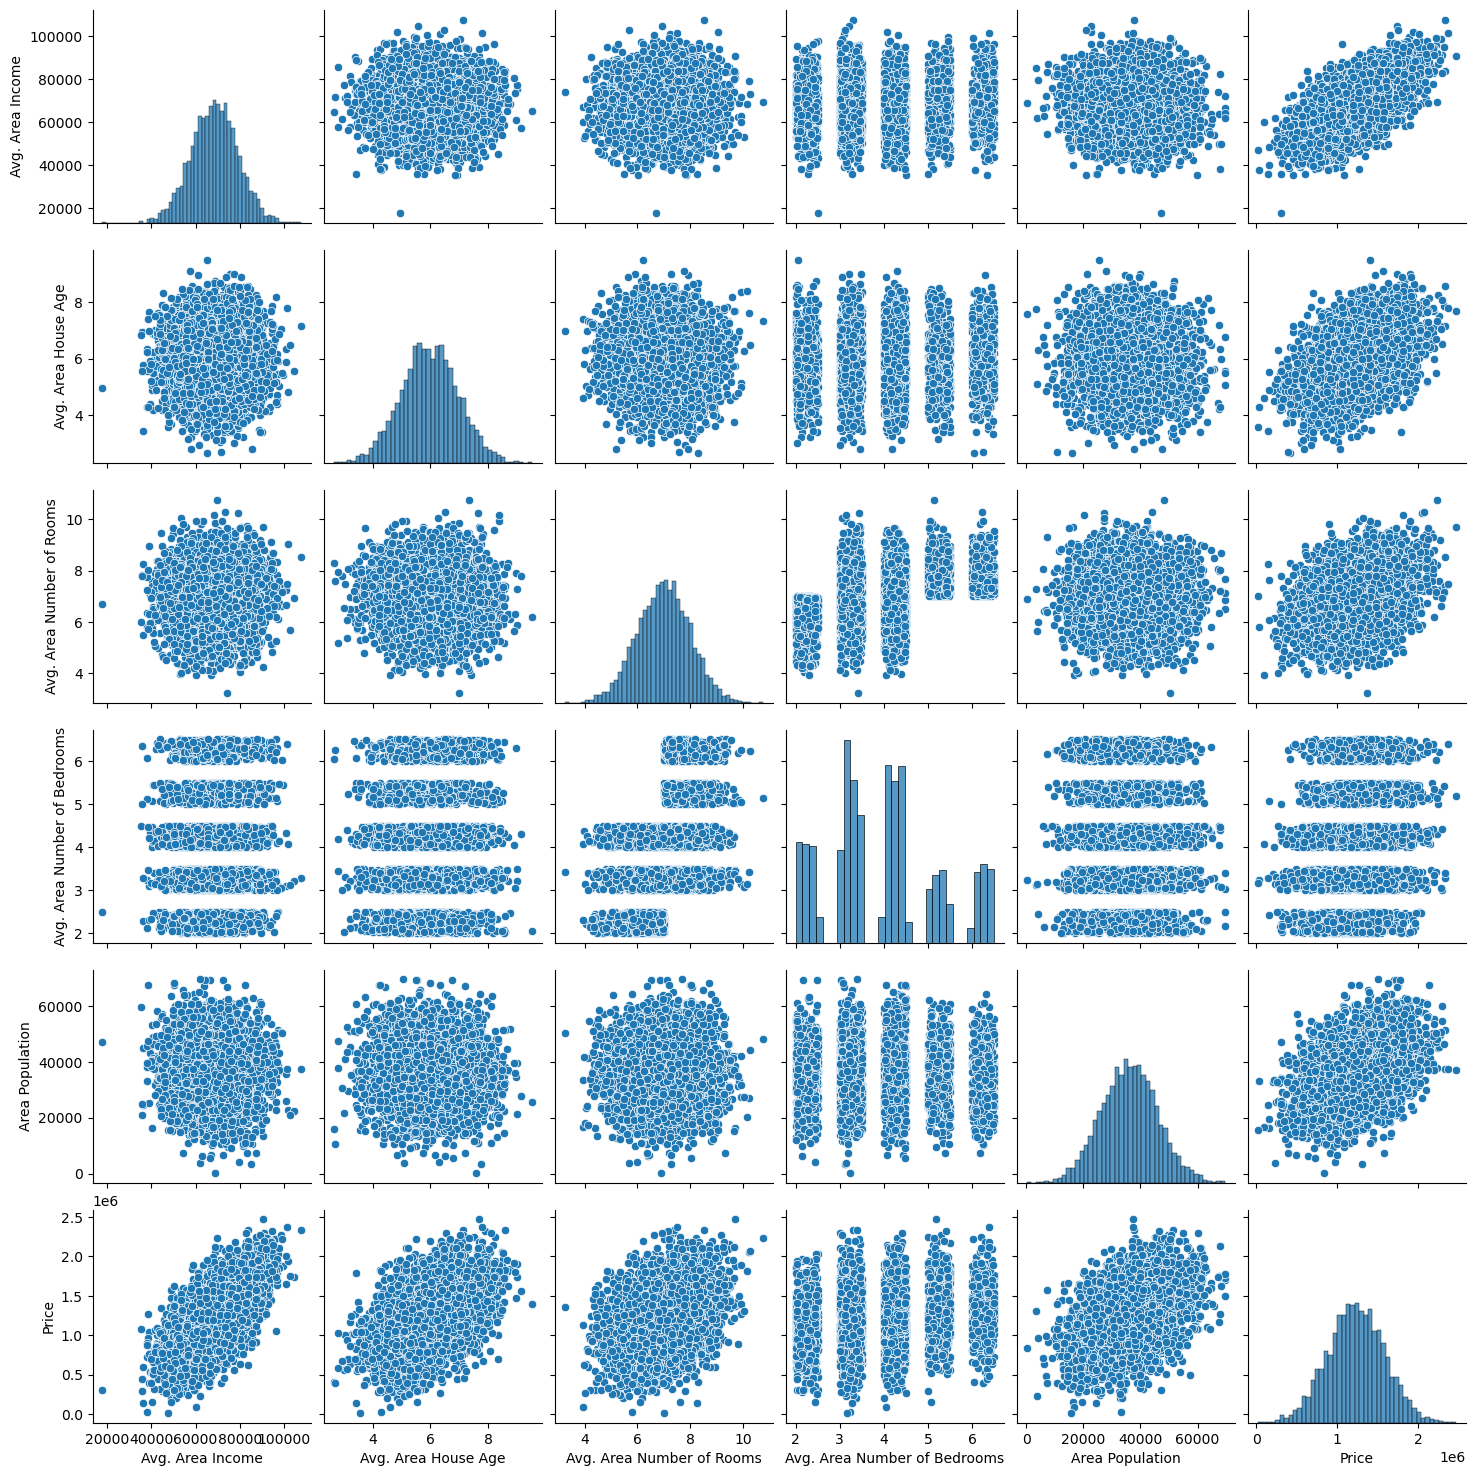

In [9]:
sns.pairplot(df)
plt.show()

### Draw a heatmap to identify the correlation

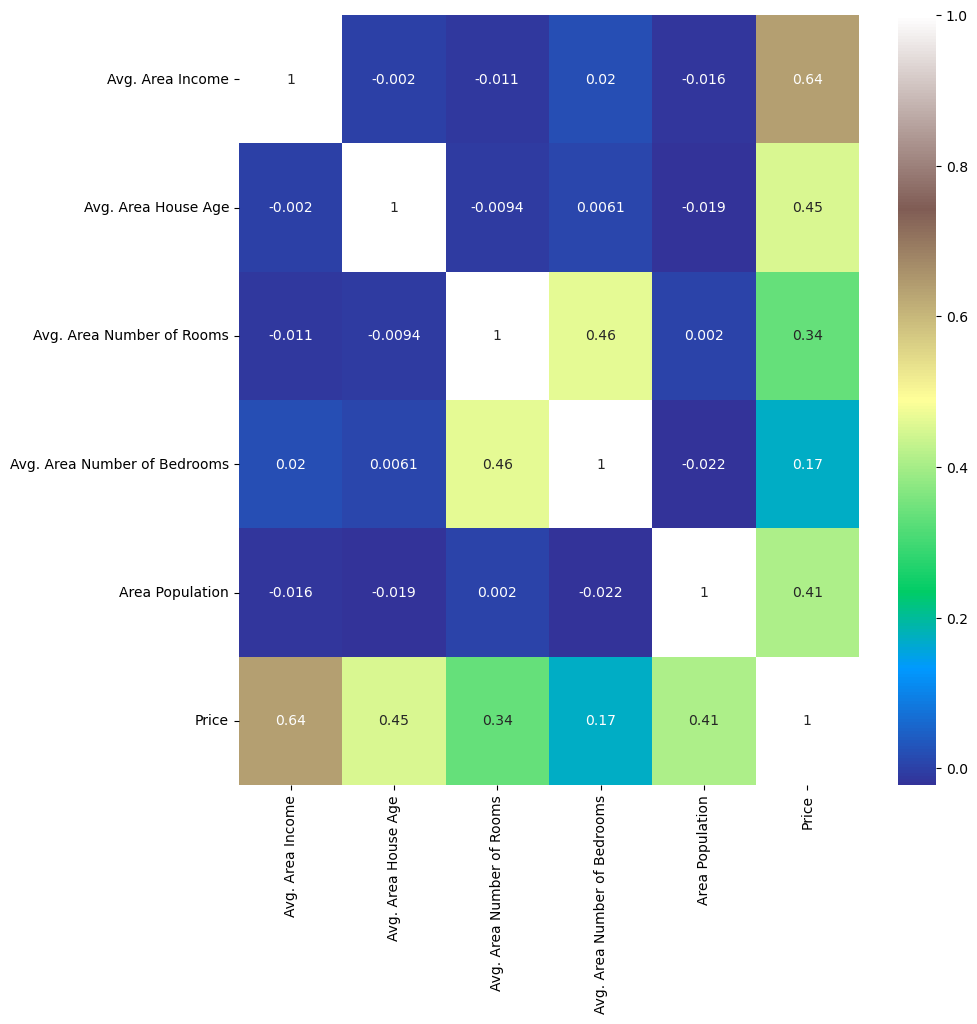

In [10]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,cmap='terrain')
plt.show()

### Assign features and target on X and y variable

In [11]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [12]:
X=df.drop(columns=['Price'])
y=df['Price']

### Check the shape of X and y

In [13]:
X.shape

(5000, 5)

In [14]:
y.shape

(5000,)

In [15]:
# X must be a 2D array and y must be a 1D array

### Standardise the data using StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()

In [18]:
xcolumns=X.columns.tolist()

In [19]:
X=scaler.fit_transform(X)

In [20]:
X=pd.DataFrame(X,columns=xcolumns)

In [21]:
X.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,1.028660,-0.296927,0.021274,0.088062,-1.317599
1,1.000808,0.025902,-0.255506,-0.722301,0.403999
2,-0.684629,-0.112303,1.516243,0.930840,0.072410
3,-0.491499,1.221572,-1.393077,-0.584540,-0.186734
4,-0.807073,-0.944834,0.846742,0.201513,-0.988387


### Split the data into training and testing set

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=100)

### Check the size of X_train and X_test

In [24]:
X_train.shape

(3500, 5)

In [25]:
X_test.shape

(1500, 5)

### Create a Linear Regression model and train it

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
# Create the model
model=LinearRegression()

In [28]:
# Train the model
model.fit(X_train,y_train)

LinearRegression()

### Check the score of our model

In [29]:
model.score(X_train,y_train)

0.9177663558654594

### Print the Intercept

In [30]:
print(model.intercept_)

1232093.688156182


### Print the coefficents

In [31]:
print(model.coef_)

[230209.40788848 164236.01176989 120894.02898197    682.06883626
 151435.13160062]


In [32]:
pd.DataFrame(model.coef_,index=X_test.columns,columns=['Coefficient'])

,Coefficient
Avg. Area Income,230209.407888
Avg. Area House Age,164236.011770
Avg. Area Number of Rooms,120894.028982
Avg. Area Number of Bedrooms,682.068836
Area Population,151435.131601


### Predict using the X_test and  store the values in a variable

In [33]:
y_pred=model.predict(X_test)

In [34]:
y_pred

array([ 813136.75469429, 1563236.09165626, 1321396.08341461, ...,
       1463524.93474975,  388153.36825074, 1032634.27163485])

### Calculate the mean squared error and r2 score

In [35]:
from sklearn import metrics


In [36]:
metrics.mean_absolute_error(y_test,y_pred)

81522.14854304126

In [37]:
#mean_squared_error
metrics.mean_squared_error(y_test,y_pred)

10340528517.994562

In [38]:
#r2 score
metrics.r2_score(y_test,y_pred)

0.9185284140631064

### Create a scatterplot to visualize actual value vs predicted values

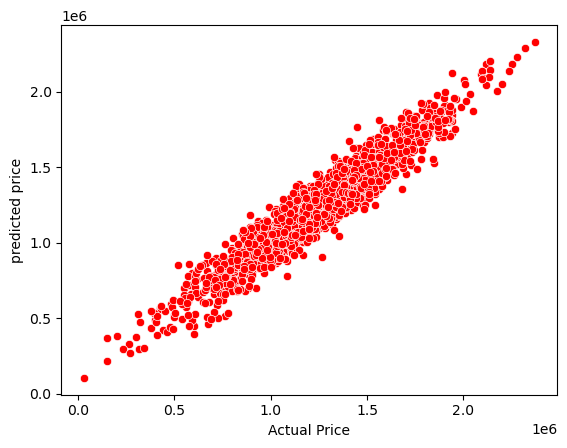

In [39]:
sns.scatterplot(x=y_test,y=y_pred,color='red')
plt.xlabel('Actual Price')
plt.ylabel('predicted price')
plt.show()

to check accuracy

In [40]:
len(y_pred)

1500

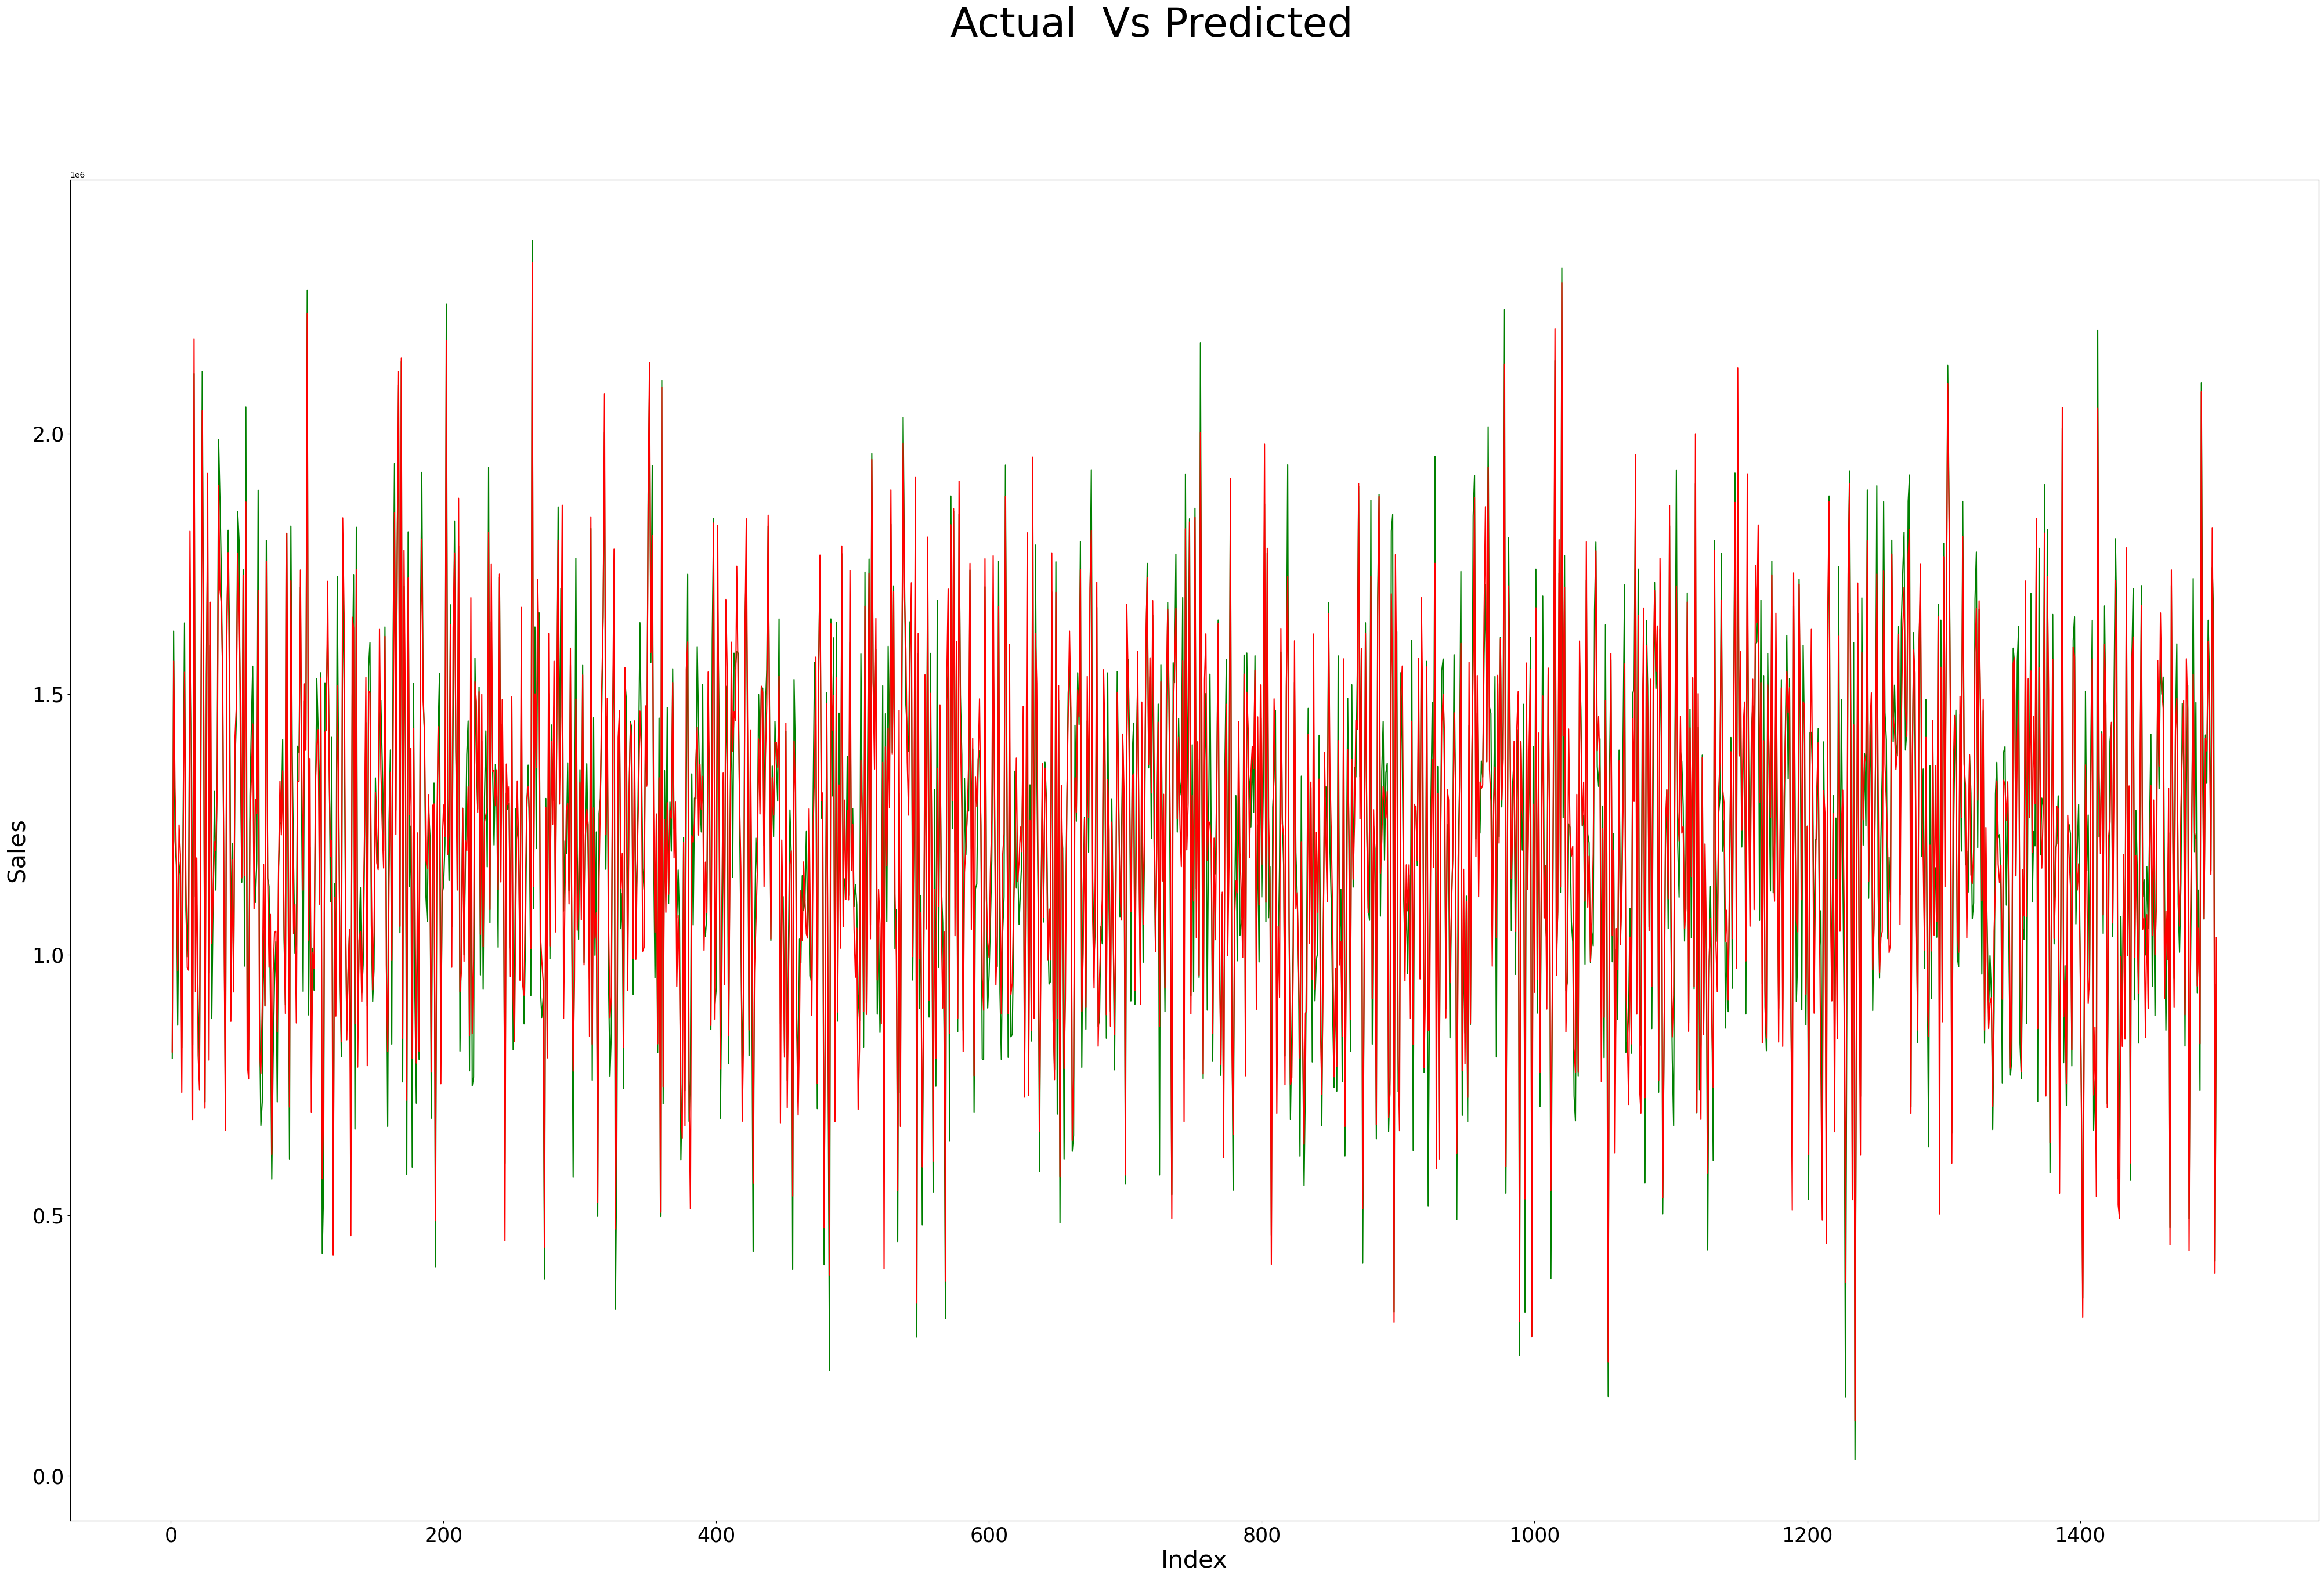

In [50]:
c = [i for i in range(1,1501,1)] 
fig = plt.figure(figsize=(50,30))
plt.plot(c,y_test, color = 'green') 
plt.plot(c,y_pred, color = 'red') 
fig.suptitle('Actual  Vs Predicted ',fontsize=50) 
plt.xlabel('Index',fontsize=30) 
plt.ylabel('Sales',fontsize=30) 
plt.xticks(fontsize=25) 
plt.yticks(fontsize=25)
plt.show()

***